In [1]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import random

In [2]:
# Run this once to load the train and test data straight into a dataloader class
# that will provide the batches
batch_size_train = 64
batch_size_test = 1000
train_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('/files/', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
  batch_size=batch_size_train, shuffle=True)

test_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('/files/', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
  batch_size=batch_size_test, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.04MB/s]


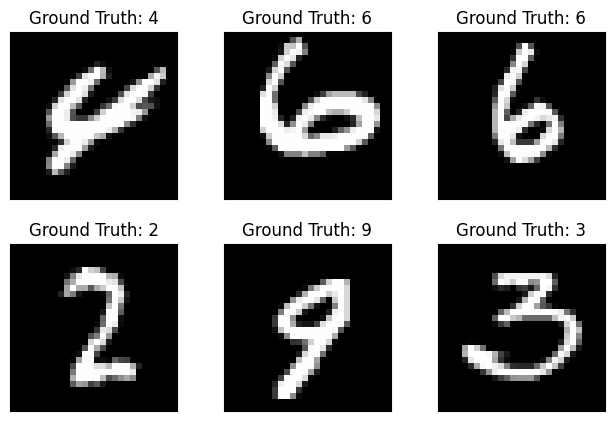

In [4]:
# Let's draw some of the training data
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])
plt.show()

In [5]:
from os import X_OK
# TODO Change this class to implement
# 1. A valid convolution with kernel size 5, 1 input channel and 10 output channels
# 2. A max pooling operation over a 2x2 area
# 3. A Relu
# 4. A valid convolution with kernel size 5, 10 input channels and 20 output channels
# 5. A 2D Dropout layer
# 6. A max pooling operation over a 2x2 area
# 7. A relu
# 8. A flattening operation
# 9. A fully connected layer mapping from (whatever dimensions we are at-- find out using .shape) to 50
# 10. A ReLU
# 11. A fully connected layer mapping from 50 to 10 dimensions
# 12. A softmax function.

# Replace this class which implements a minimal network (which still does okay)
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Valid convolution, 1 channel in, 2 channels out, stride 1, kernel size = 3

        self.conv1 = nn.Conv2d(1, 2, kernel_size=3) #par défaut pading = 0

        # Dropout for convolutions
        self.drop = nn.Dropout2d()
        # Fully connected layer
        self.fc1 = nn.Linear(338, 10) # 338 carte de caracteristique aplati 2*14*14 C-in * H * W

    def forward(self, x):
        x = self.conv1(x)
        x = self.drop(x)
        x = F.max_pool2d(x,2)
        x = F.relu(x)
        x = x.flatten(1)
        x = self.fc1(x)
        x = F.log_softmax(x)
        return x

In [6]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Step 1: Conv2d - 1 input channel, 10 output channels, kernel size 5, valid padding
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)

        # Step 4: Conv2d - 10 input channels, 20 output channels, kernel size 5, valid padding
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)

        # Step 5: Dropout2d
        self.dropout = nn.Dropout2d()

        # Step 9: Fully connected layer (after calculating the flattened size)
        # MNIST input is 28x28
        # After conv1 + kernel 5 →
        size: 28 - 5 + 1 = 24
        # MaxPool 2x2 → 24 / 2 = 12
        # conv2 with kernel 5 → 12 - 5 + 1 = 8
        # MaxPool 2x2 → 8 / 2 = 4
        # Final feature map: 20 channels, 4x4 spatial size → 20 * 4 * 4 = 320
        self.fc1 = nn.Linear(320, 50)

        # Step 11: Fully connected from 50 → 10
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        # Step 1: Conv + Step 2: MaxPool + Step 3: ReLU
        x = F.relu(F.max_pool2d(self.conv1(x), 2))

        # Step 4: Conv + Step 5: Dropout + Step 6: MaxPool + Step 7: ReLU
        x = F.relu(F.max_pool2d(self.dropout(self.conv2(x)), 2))

        # Step 8: Flatten
        x = torch.flatten(x, 1)  # Flatten all dimensions except batch

        # Step 9: Fully connected to 50
        x = self.fc1(x)

        # Step 10: ReLU
        x = F.relu(x)

        # Step 11: Fully connected to 10
        x = self.fc2(x)

        # Step 12: Softmax
        x = F.log_softmax(x, dim=1)  # Log softmax for classification

        return x


In [7]:
# He initialization of weights
def weights_init(layer_in):
  if isinstance(layer_in, nn.Linear):
    nn.init.kaiming_uniform_(layer_in.weight)
    layer_in.bias.data.fill_(0.0)

In [8]:
# Create network
model = Net() # if we want to use gpu we do Net().yoda
# Initialize model weights
model.apply(weights_init)
# Define optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)

In [9]:
# Main training routine
def train(epoch):
  model.train()
  # Get each
  for batch_idx, (data, target) in enumerate(train_loader):
    optimizer.zero_grad()
    output = model(data)
    loss = F.nll_loss(output, target)
    loss.backward()
    optimizer.step()
    # Store results
    if batch_idx % 10 == 0:
      print('Train Epoch: {} [{}/{}]\tLoss: {:.6f}'.format(
        epoch, batch_idx * len(data), len(train_loader.dataset), loss.item()))

In [10]:
# Run on test data
def test():
  model.eval()
  test_loss = 0
  correct = 0
  with torch.no_grad(): #important
    for data, target in test_loader:
      output = model(data)
      test_loss += F.nll_loss(output, target, size_average=False).item()
      pred = output.data.max(1, keepdim=True)[1]
      correct += pred.eq(target.data.view_as(pred)).sum()
  test_loss /= len(test_loader.dataset)
  print('\nTest set: Avg. loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
    test_loss, correct, len(test_loader.dataset),
    100. * correct / len(test_loader.dataset)))

In [11]:
# Get initial performance
test()
# Train for three epochs
n_epochs = 3
for epoch in range(1, n_epochs + 1):
  train(epoch)
  test()

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:3178: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  reduction = _Reduction.legacy_get_string(size_average, reduce)



Test set: Avg. loss: 2.4536, Accuracy: 898/10000 (9%)

Train Epoch: 1 [0/60000]	Loss: 2.559299
Train Epoch: 1 [640/60000]	Loss: 2.269794
Train Epoch: 1 [1280/60000]	Loss: 2.143970
Train Epoch: 1 [1920/60000]	Loss: 2.035845
Train Epoch: 1 [2560/60000]	Loss: 1.843987
Train Epoch: 1 [3200/60000]	Loss: 1.668787
Train Epoch: 1 [3840/60000]	Loss: 1.612311
Train Epoch: 1 [4480/60000]	Loss: 1.311494
Train Epoch: 1 [5120/60000]	Loss: 1.063734
Train Epoch: 1 [5760/60000]	Loss: 1.229653
Train Epoch: 1 [6400/60000]	Loss: 1.030877
Train Epoch: 1 [7040/60000]	Loss: 0.841891
Train Epoch: 1 [7680/60000]	Loss: 0.592976
Train Epoch: 1 [8320/60000]	Loss: 0.584972
Train Epoch: 1 [8960/60000]	Loss: 0.656907
Train Epoch: 1 [9600/60000]	Loss: 0.659974
Train Epoch: 1 [10240/60000]	Loss: 0.428152
Train Epoch: 1 [10880/60000]	Loss: 0.761652
Train Epoch: 1 [11520/60000]	Loss: 0.458214
Train Epoch: 1 [12160/60000]	Loss: 0.825744
Train Epoch: 1 [12800/60000]	Loss: 0.424069
Train Epoch: 1 [13440/60000]	Loss: 0.531

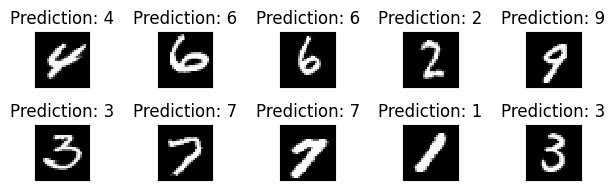

In [13]:
# Run network on data we got before and show predictions
output = model(example_data)

fig = plt.figure()
for i in range(10):
  plt.subplot(5,5,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Prediction: {}".format(
    output.data.max(1, keepdim=True)[1][i].item()))
  plt.xticks([])
  plt.yticks([])
plt.show()